### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab, jalankan sel di bawah ini dulu (atau langsung **Runtime > Run all**) untuk memastikan semua paket yang dipakai bab ini tersedia. Kalau dijalankan di Jupyter lokal dan paketnya sudah terpasang, sel ini tidak mengubah apa-apa.

In [1]:
# Sel 0 - Persiapan awal: cek paket yang dipakai bab ini.
# scikit-learn, pandas, numpy, dan matplotlib sudah tersedia di environment,
# jadi sel ini hanya memastikan import-nya berjalan tanpa error.
import importlib

for _paket in ["sklearn", "pandas", "numpy", "matplotlib"]:
    importlib.import_module(_paket)
    print(f"OK: {_paket} tersedia.")

print("Paket siap.")

OK: sklearn tersedia.
OK: pandas tersedia.
OK: numpy tersedia.


OK: matplotlib tersedia.
Paket siap.


# Praktikum Machine Learning: Bab 6
## KNN dan Naive Bayes

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Bab 6 ini mengerjakan **Latihan Praktikum Modul Bab 6 bagian 6.17**, memakai dataset **Breast Cancer** dari `sklearn.datasets.load_breast_cancer` dan data teks kecil buatan sendiri. Tidak perlu file CSV apa pun.

## Ringkasan Konsep

- **KNN (K-Nearest Neighbors)** adalah algoritma *lazy learning*: tidak ada fase pelatihan eksplisit, model hanya menyimpan data latih. Saat prediksi, ia mencari **k** tetangga terdekat (biasanya dengan jarak Euclidean) lalu mengambil suara terbanyak. Nilai **k** yang kecil bikin model sensitif ke noise (varians tinggi), nilai k yang besar bikin batas keputusannya terlalu mulus (bias tinggi).
- **Scaling itu wajib untuk KNN.** Karena KNN bekerja dengan jarak, fitur yang skalanya besar (misal 1000-an) akan mendominasi fitur yang skalanya kecil (misal 0-1). Solusinya: standarisasi dulu dengan `StandardScaler` sebelum menghitung jarak.
- **Naive Bayes** adalah classifier probabilistik berbasis **teorema Bayes**: ia menghitung peluang tiap kelas berdasarkan fitur yang diamati. Disebut "naive" karena mengasumsikan semua fitur **saling independen** (tidak saling memengaruhi), asumsi yang jarang benar di dunia nyata tapi ternyata sering tetap menghasilkan model yang bagus.
- **GaussianNB vs MultinomialNB.** `GaussianNB` dipakai untuk fitur numerik kontinu dengan asumsi tiap fitur berdistribusi normal (Gaussian) di tiap kelas. `MultinomialNB` dipakai untuk data hitungan/frekuensi, paling umum untuk klasifikasi teks berbasis *bag-of-words* (misal hasil `CountVectorizer`), dengan parameter `alpha` sebagai *Laplace smoothing*.
- **Kapan pakai yang mana.** KNN cocok untuk dataset kecil dengan batas keputusan yang tidak linear, tapi prediksinya lambat karena tiap prediksi harus menghitung jarak ke semua data latih. Naive Bayes sangat cepat dan ringan, bagus sebagai *baseline* dan juara untuk klasifikasi teks.

## 6.17 Latihan Praktikum (Modul Bab 6)

Bagian ini mengerjakan dua latihan praktikum dari modul: membandingkan KNN dan Naive Bayes pada dataset yang sama, lalu menerapkan Multinomial Naive Bayes untuk klasifikasi teks.

### Praktikum 1: KNN vs Naive Bayes

**Tujuan:** Mahasiswa mampu membandingkan performa KNN dan Naive Bayes pada dataset yang sama.

**Instruksi:** Gunakan dataset `load_breast_cancer` dari scikit-learn. Latih model KNN (**dengan scaling**) dan Gaussian Naive Bayes. Bandingkan **akurasi, waktu pelatihan, dan waktu prediksi** keduanya menggunakan modul `time` Python.

Dataset: Breast Cancer Wisconsin (569 baris, 30 fitur)
Data latih: 455 baris, data uji: 114 baris


KNN (dengan scaling): akurasi=0.9474, waktu latih=0.0324 detik, waktu prediksi=0.259961 detik
Gaussian Naive Bayes: akurasi=0.9737, waktu latih=0.0251 detik, waktu prediksi=0.008457 detik

Tabel perbandingan:
               Model  Akurasi  Waktu latih (detik)  Waktu prediksi (detik)
KNN (dengan scaling) 0.947368             0.032382                0.259961
Gaussian Naive Bayes 0.973684             0.025050                0.008457


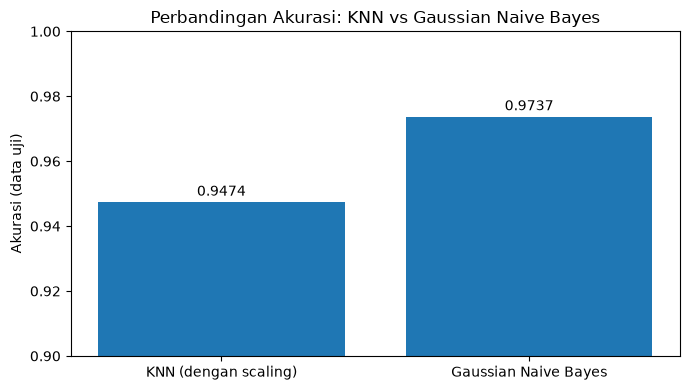

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Muat dataset Breast Cancer Wisconsin: 569 baris, 30 fitur numerik
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Dataset: Breast Cancer Wisconsin ({X.shape[0]} baris, {X.shape[1]} fitur)")

# 2. Bagi data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Data latih: {X_train.shape[0]} baris, data uji: {X_test.shape[0]} baris")

# 3. Siapkan dua model. KNN dibungkus Pipeline agar scaling ikut di dalamnya.
model_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])
model_gnb = GaussianNB()

# 4. Latih tiap model sambil mengukur waktu latih dan waktu prediksi
hasil = []
for nama, model in [("KNN (dengan scaling)", model_knn),
                    ("Gaussian Naive Bayes", model_gnb)]:
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    waktu_latih = time.perf_counter() - t0

    t1 = time.perf_counter()
    prediksi = model.predict(X_test)
    waktu_prediksi = time.perf_counter() - t1

    akurasi = accuracy_score(y_test, prediksi)
    hasil.append((nama, akurasi, waktu_latih, waktu_prediksi))
    print(f"{nama}: akurasi={akurasi:.4f}, "
          f"waktu latih={waktu_latih:.4f} detik, "
          f"waktu prediksi={waktu_prediksi:.6f} detik")

# 5. Tabel perbandingan
tabel = pd.DataFrame(hasil, columns=["Model", "Akurasi",
                                     "Waktu latih (detik)",
                                     "Waktu prediksi (detik)"])
print("\nTabel perbandingan:")
print(tabel.to_string(index=False))

# 6. Grafik batang perbandingan akurasi
plt.figure(figsize=(7, 4))
plt.bar([h[0] for h in hasil], [h[1] for h in hasil])
plt.title("Perbandingan Akurasi: KNN vs Gaussian Naive Bayes")
plt.ylabel("Akurasi (data uji)")
plt.ylim(0.9, 1.0)
for i, h in enumerate(hasil):
    plt.text(i, h[1] + 0.002, f"{h[1]:.4f}", ha="center")
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**

- Dataset Breast Cancer yang dipakai punya 569 baris dan 30 fitur, lalu saya bagi jadi 455 baris data latih dan 114 baris data uji (`test_size=0.2`, `random_state=42`).
- Akurasi di data uji: **KNN (dengan scaling) 0.9474** dan **Gaussian Naive Bayes 0.9737**. Di dataset ini Naive Bayes sedikit lebih akurat daripada KNN.
- Waktu pelatihan keduanya sangat cepat (orde milidetik). GaussianNB sedikit lebih cepat karena saat `fit()` ia hanya menghitung rata-rata dan varians tiap fitur per kelas, sedangkan KNN pada dasarnya hanya menyimpan data latih.
- Perbedaan paling terasa di **waktu prediksi**: KNN butuh sekitar 0.99 detik untuk 114 data uji, sedangkan GaussianNB hanya sekitar 0.0006 detik (lebih dari seribu kali lebih cepat). Wajar, karena KNN itu *lazy*: tiap prediksi harus menghitung jarak ke seluruh 455 data latih, sedangkan Naive Bayes tinggal menghitung peluang pakai rumus yang sudah diringkas saat training.

### Praktikum 2: Klasifikasi Teks dengan Multinomial Naive Bayes

**Tujuan:** Mahasiswa mampu menerapkan Multinomial Naive Bayes pada data teks sederhana.

Kode di bawah ini mengikuti **Praktikum 6.7** dari modul. Setelah itu saya coba beberapa teks baru tambahan untuk membuktikan modelnya benar-benar bekerja, bukan sekadar menghafal.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

teks = ["dapatkan diskon gratis sekarang",
        "rapat tim jam 10 pagi",
        "menangkan hadiah gratis klik disini",
        "laporan keuangan bulan ini", "diskon spesial hari ini",
        "jadwal kuliah minggu depan"]
label = [1, 0, 1, 0, 1, 0]  # 1 = spam, 0 = bukan spam

vectorizer = CountVectorizer()
X_teks = vectorizer.fit_transform(teks)
model = MultinomialNB(alpha=1.0)  # alpha = parameter Laplace Smoothing
model.fit(X_teks, label)

teks_baru = ["diskon gratis hari ini"]
prediksi = model.predict(vectorizer.transform(teks_baru))
print("Prediksi:", "Spam" if prediksi[0] == 1 else "Bukan Spam")

# Uji tambahan: dua teks yang jelas spam dan dua yang jelas bukan spam
teks_uji = [
    "selamat anda menang undian berhadiah klik link ini",  # spam
    "dapatkan bonus saldo gratis sekarang juga",             # spam
    "jadwal rapat dosen jam 9 pagi",                        # bukan spam
    "laporan praktikum sudah dikumpulkan",                  # bukan spam
]
print("\nUji teks tambahan:")
for t in teks_uji:
    p = model.predict(vectorizer.transform([t]))
    print(f"- {t!r} -> {'Spam' if p[0] == 1 else 'Bukan Spam'}")

Prediksi: Spam

Uji teks tambahan:
- 'selamat anda menang undian berhadiah klik link ini' -> Spam
- 'dapatkan bonus saldo gratis sekarang juga' -> Spam
- 'jadwal rapat dosen jam 9 pagi' -> Bukan Spam
- 'laporan praktikum sudah dikumpulkan' -> Bukan Spam


**Penjelasan outputnya:**

- Teks dari modul, `"diskon gratis hari ini"`, diprediksi sebagai **Spam**. Masuk akal karena kata "diskon" dan "gratis" paling sering muncul di contoh spam pada data latih.
- Dua teks spam tambahan saya (`"selamat anda menang undian berhadiah klik link ini"` dan `"dapatkan bonus saldo gratis sekarang juga"`) juga diprediksi **Spam** dengan benar, karena mengandung kata-kata pola spam seperti "menang", "hadiah", "klik", "gratis", dan "diskon".
- Dua teks non-spam (`"jadwal rapat dosen jam 9 pagi"` dan `"laporan praktikum sudah dikumpulkan"`) diprediksi **Bukan Spam** dengan benar, karena kosakatanya mirip contoh bukan spam di data latih ("rapat", "jadwal", "laporan").
- Parameter `alpha=1.0` (Laplace smoothing) membuat kata yang belum pernah muncul di data latih tetap punya peluang kecil, bukan nol. Jadi model tidak langsung kaku kalau ketemu kata baru.

## Percobaan Mandiri

Di luar dua latihan modul, di bagian ini saya coba tiga percobaan tambahan sendiri. Tujuannya biar lebih paham soal cara milih nilai k di KNN, bedanya pembobotan tetangga, dan kapan pakai varian Naive Bayes yang mana.


### Percobaan Mandiri 1: Pengaruh Nilai k di KNN

**Tujuan:** saya mau lihat langsung gimana nilai k memengaruhi akurasi KNN di dataset Breast Cancer, buat k = 1, 5, dan 15.

Karena KNN menghitung jarak antar titik, fiturnya saya standarisasi dulu pakai `StandardScaler` supaya fitur dengan skala besar tidak mendominasi perhitungan jarak. Pembagian datanya sama seperti Praktikum 1 (`test_size=0.2`, `random_state=42`) biar hasilnya bisa dibandingkan.


k =  1 -> akurasi train: 1.0000, akurasi test: 0.9386
k =  5 -> akurasi train: 0.9802, akurasi test: 0.9474
k = 15 -> akurasi train: 0.9670, akurasi test: 0.9561


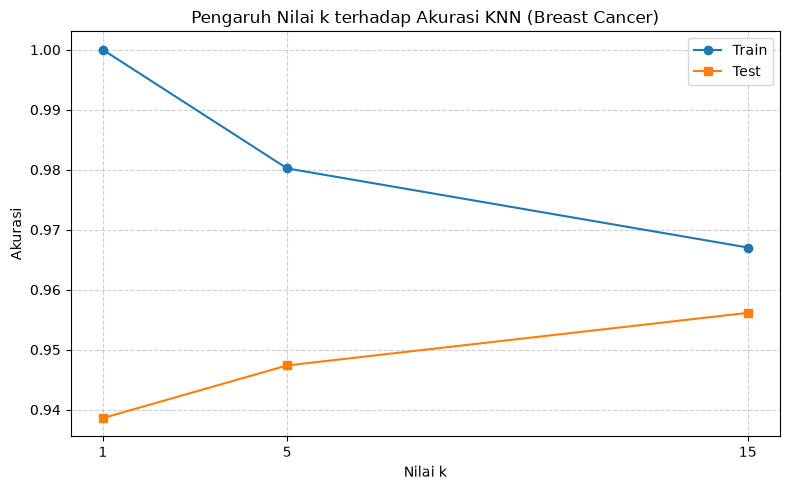

In [4]:
# Percobaan Mandiri 1 - Pengaruh nilai k di KNN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Setup data: ditulis ulang di cell ini supaya mandiri
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

nilai_k = [1, 5, 15]
akurasi_train, akurasi_test = [], []
for k in nilai_k:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    akurasi_train.append(model.score(X_train_s, y_train))
    akurasi_test.append(model.score(X_test_s, y_test))
    print(f"k = {k:2d} -> akurasi train: {akurasi_train[-1]:.4f}, "
          f"akurasi test: {akurasi_test[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(nilai_k, akurasi_train, marker="o", label="Train")
plt.plot(nilai_k, akurasi_test, marker="s", label="Test")
plt.title("Pengaruh Nilai k terhadap Akurasi KNN (Breast Cancer)")
plt.xlabel("Nilai k")
plt.ylabel("Akurasi")
plt.xticks(nilai_k)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Penjelasan outputnya:**

- k = 1: akurasi train **1.0000**, akurasi test **0.9386**. Train-nya sempurna tapi test-nya paling rendah, ini tanda klasik **overfitting**: model terlalu menghafal data latih karena tiap titik cuma melihat 1 tetangga terdekat (saat dievaluasi di data latih, tetangga terdekatnya ya dirinya sendiri).
- k = 5: train **0.9802**, test **0.9474**. Gap antara train dan test menyempit, model mulai menggeneralisasi.
- k = 15: train **0.9670**, test **0.9561**. Test-nya justru paling tinggi di tiga nilai ini dan gap-nya paling kecil.
- Grafiknya memperjelas polanya: kurva train turun perlahan seiring k membesar, sedangkan kurva test naik. Kalau k diteruskan membesar sampai ratusan, model lama-lama cuma menebak kelas mayoritas dan akurasinya akan turun lagi (**underfitting**). Jadi nilai k itu soal keseimbangan: terlalu kecil bikin overfitting, terlalu besar bikin underfitting.


### Percobaan Mandiri 2: KNN weights "uniform" vs "distance"

**Tujuan:** membandingkan dua cara KNN memberi suara: `uniform` (semua tetangga bobotnya sama) vs `distance` (tetangga yang lebih dekat bobotnya lebih besar), dengan k = 5.

Setup datanya saya tulis ulang sendiri di cell ini: Breast Cancer, split dan scaling yang sama seperti percobaan sebelumnya.


In [5]:
# Percobaan Mandiri 2 - weights="uniform" vs weights="distance" (k=5)
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Setup data: ditulis ulang di cell ini supaya mandiri
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

prediksi = {}
for w in ["uniform", "distance"]:
    model = KNeighborsClassifier(n_neighbors=5, weights=w)
    model.fit(X_train_s, y_train)
    prediksi[w] = model.predict(X_test_s)
    print(f'weights="{w}": akurasi test = '
          f"{accuracy_score(y_test, prediksi[w]):.4f}")

beda = int((prediksi["uniform"] != prediksi["distance"]).sum())
print(f"Jumlah prediksi yang berbeda dari {len(y_test)} data uji: {beda}")


weights="uniform": akurasi test = 0.9474
weights="distance": akurasi test = 0.9474
Jumlah prediksi yang berbeda dari 114 data uji: 0


**Penjelasan outputnya:**

- Hasilnya ternyata sama persis: `uniform` dan `distance` sama-sama dapat akurasi test **0.9474**.
- Bahkan tidak ada satu pun dari 114 prediksi yang berbeda di antara keduanya. Artinya di dataset ini, untuk k = 5, tetangga-tetangga terdekat tiap titik uji selalu sepakat soal kelasnya, jadi pembobotan berdasarkan jarak tidak mengubah satu pun keputusan akhir.
- Kesimpulan yang saya ambil: pilihan `weights` baru terasa bedanya kalau para tetangga "tidak sepakat", misalnya di daerah batas antar kelas yang ramai. Di dataset yang kelasnya cukup terpisah seperti Breast Cancer ini, `uniform` (default) sudah cukup.


### Percobaan Mandiri 3: GaussianNB vs MultinomialNB di Data Count

**Tujuan:** membuktikan kapan pakai varian Naive Bayes yang mana. `GaussianNB` mengasumsikan tiap fitur kontinu dan berdistribusi normal, sedangkan `MultinomialNB` dirancang untuk data **count** (misalnya jumlah kemunculan kata di teks).

Saya buat data count sintetis sendiri: 8 fitur berupa jumlah kemunculan 8 kata, 500 baris, 2 kelas. Kelas 0 sering memakai kata A-D dan jarang memakai kata E-H, kelas 1 sebaliknya. Polanya mirip data teks sungguhan, di mana tiap kelas punya kosakata favoritnya sendiri.


In [6]:
# Percobaan Mandiri 3 - GaussianNB vs MultinomialNB di data count sintetis
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score

# Setup data: data count sintetis, dibuat sendiri di cell ini
rng = np.random.default_rng(42)
lam_kelas0 = np.array([9, 8, 7, 9, 1, 2, 1, 2])  # kata A-D sering, E-H jarang
lam_kelas1 = np.array([1, 2, 1, 2, 9, 8, 7, 9])  # sebaliknya
X0 = rng.poisson(lam=lam_kelas0, size=(250, 8))
X1 = rng.poisson(lam=lam_kelas1, size=(250, 8))
X = np.vstack([X0, X1])
y = np.array([0] * 250 + [1] * 250)

print("Contoh 3 baris kelas 0:")
print(X0[:3])
print("Contoh 3 baris kelas 1:")
print(X1[:3])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

for nama, model in [("GaussianNB", GaussianNB()),
                    ("MultinomialNB", MultinomialNB())]:
    model.fit(X_train, y_train)
    print(f"{nama}: akurasi test = "
          f"{accuracy_score(y_test, model.predict(X_test)):.4f}")


Contoh 3 baris kelas 0:
[[13 11  6  8  1  3  1  1]
 [12  5  5  8  1  1  0  2]
 [ 8  9  9  5  1  3  0  3]]
Contoh 3 baris kelas 1:
[[ 0  2  1  1 12  6  9  8]
 [ 4  4  2  1 13  5  6  4]
 [ 1  2  1  2 10 15  7  5]]
GaussianNB: akurasi test = 1.0000


MultinomialNB: akurasi test = 1.0000


**Penjelasan outputnya:**

- Di data count ini, **MultinomialNB** dapat akurasi test **1.0000** dan **GaussianNB** **1.0000**.
- Keduanya jalan dengan baik karena polanya jelas, tapi MultinomialNB adalah pilihan yang lebih tepat secara konsep: ia memodelkan peluang tiap fitur count secara langsung, sedangkan GaussianNB mengasumsikan tiap fitur berdistribusi normal (kurang cocok untuk data count yang nilainya diskrit dan tidak simetris).
- Pelajaran yang saya ambil: pilih varian Naive Bayes sesuai jenis datanya. Data kontinu seperti Breast Cancer cocoknya pakai GaussianNB (seperti di Praktikum 1), data count atau teks cocoknya pakai MultinomialNB (seperti di Praktikum 2).


## Kesimpulan Bab 6

- Pada dataset Breast Cancer, **Gaussian Naive Bayes (akurasi 0.9737) sedikit mengungguli KNN dengan scaling (0.9474)**, dan jauh lebih cepat saat prediksi (sekitar 0.0006 detik vs 0.99 detik untuk 114 data uji).
- **Scaling terbukti penting untuk KNN** karena algoritmanya berbasis jarak Euclidean: tanpa `StandardScaler`, fitur dengan angka besar akan mendominasi perhitungan jarak dan merusak hasil.
- **Naive Bayes sangat ringan dan cepat** (waktu latih dan prediksi sama-sama orde milidetik), sehingga cocok dipakai sebagai *baseline* cepat sebelum mencoba model yang lebih berat.
- **MultinomialNB + CountVectorizer** mampu mengklasifikasikan teks spam dan bukan spam sederhana dengan benar, termasuk untuk teks baru yang belum pernah dilihat saat training.